# Semana 5 — Interpretabilidad con SHAP

Un modelo con buen AUC que nadie puede explicar es difícil de adoptar en producción. Esta semana usamos SHAP (SHapley Additive exPlanations) para entender qué aprende el modelo a nivel global, a nivel de variable, y a nivel de un cliente individual. Es la habilidad que más preguntas genera en entrevistas técnicas.

---

In [2]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
shap.initjs()

X_train      = joblib.load('X_train.pkl')
X_test       = joblib.load('X_test.pkl')
y_test       = joblib.load('y_test.pkl')
pipe_xgb     = joblib.load('pipeline_xgb.pkl')
y_proba_xgb  = np.load('y_proba_xgb.npy')

with open('model_config.json') as f:
    config = json.load(f)
THRESHOLD = config['threshold']

print(f'Threshold cargado: {THRESHOLD}')
print(f'Test: {X_test.shape[0]:,} filas')

c:\Users\chall\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Threshold cargado: 0.1
Test: 1,409 filas


---
## 1. Preparar los datos transformados y los nombres de features

SHAP trabaja sobre los datos ya transformados por el Pipeline. Necesitamos extraer el preprocessor y aplicarlo antes de pasarle los datos al explainer.

In [3]:
preprocessor = pipe_xgb.named_steps['preprocessor']
model        = pipe_xgb.named_steps['classifier']

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Reconstruir nombres de columnas tras el Pipeline
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Obtener nombres dinámicamente del preprocessor
numeric_names = preprocessor.named_transformers_['num'].get_feature_names_out().tolist()
ohe_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

feature_names = numeric_names + ohe_cols

X_test_df  = pd.DataFrame(X_test_transformed,  columns=feature_names)
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

print(f'Features tras transformación: {len(feature_names)}')

Features tras transformación: 30


---
## 2. Calcular SHAP values

Para XGBoost usamos `TreeExplainer`, que es exacto y eficiente para modelos basados en árboles. Para redes neuronales o modelos lineales existen otros explainers (`DeepExplainer`, `LinearExplainer`).

In [4]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

print(f'Shape de shap_values: {shap_values.shape}')
print(f'Un valor por feature por ejemplo: {X_test_df.shape[0]} ejemplos x {X_test_df.shape[1]} features')
print()
print('Interpretación de un SHAP value:')
print('  Positivo → esa feature empuja la predicción HACIA churn')
print('  Negativo → esa feature empuja la predicción LEJOS de churn')
print('  La magnitud indica cuánto contribuye')

Shape de shap_values: (1409, 30)
Un valor por feature por ejemplo: 1409 ejemplos x 30 features

Interpretación de un SHAP value:
  Positivo → esa feature empuja la predicción HACIA churn
  Negativo → esa feature empuja la predicción LEJOS de churn
  La magnitud indica cuánto contribuye


---
## 3. Summary Plot — importancia global

Muestra qué variables importan más en promedio para todo el conjunto de test, y en qué dirección.

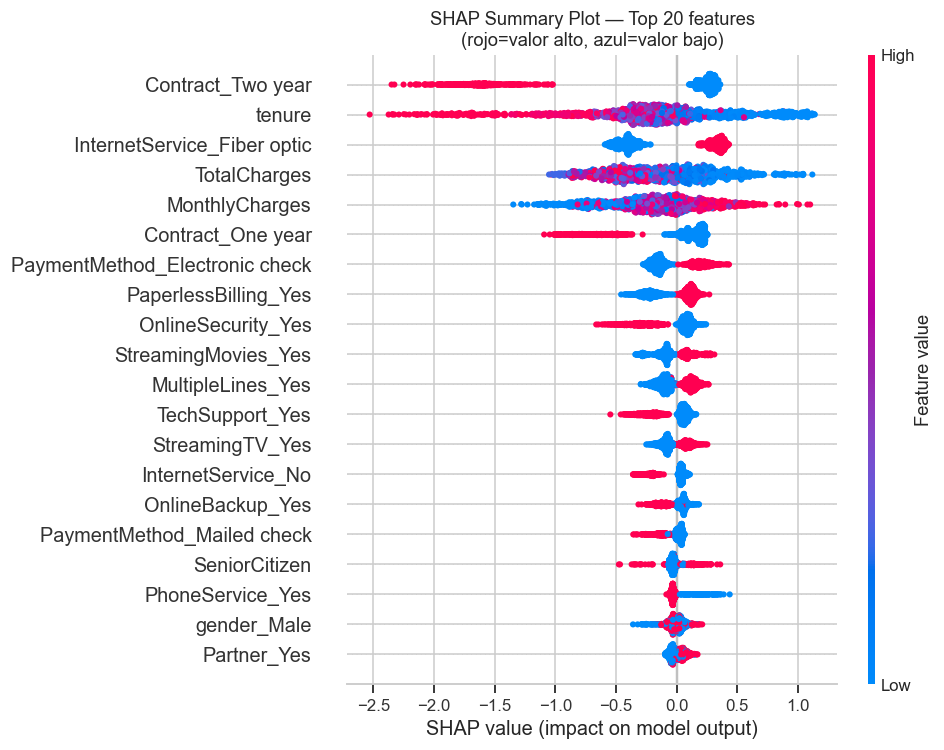


Cómo leer este gráfico:
  Eje X     → SHAP value (contribución al riesgo de churn)
  Color     → valor real de la feature (rojo=alto, azul=bajo)
  Cada punto → un cliente del test set
  Orden     → de mayor a menor importancia global (promedio |SHAP|)


In [5]:
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    X_test_df,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary Plot — Top 20 features\n(rojo=valor alto, azul=valor bajo)', fontsize=12)
plt.tight_layout()
plt.savefig('plot_15_shap_summary.png', bbox_inches='tight')
plt.show()
print()
print('Cómo leer este gráfico:')
print('  Eje X     → SHAP value (contribución al riesgo de churn)')
print('  Color     → valor real de la feature (rojo=alto, azul=bajo)')
print('  Cada punto → un cliente del test set')
print('  Orden     → de mayor a menor importancia global (promedio |SHAP|)')

---
## 4. Bar Plot — importancia media sin dirección

Versión más limpia para incluir en presentaciones o el README.

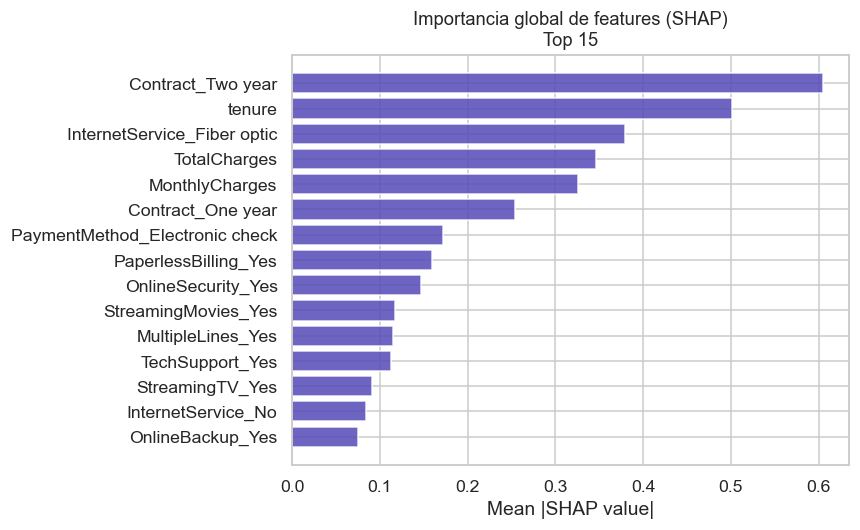

In [6]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1],
        color='#534AB7', edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Importancia global de features (SHAP)\nTop 15', fontsize=12)
plt.tight_layout()
plt.savefig('plot_16_shap_bar.png', bbox_inches='tight')
plt.show()

---
## 5. Dependence Plot — relación entre una feature y su impacto

Muestra cómo varía el SHAP value de una feature según su valor real, coloreado por la feature que más interactúa con ella.

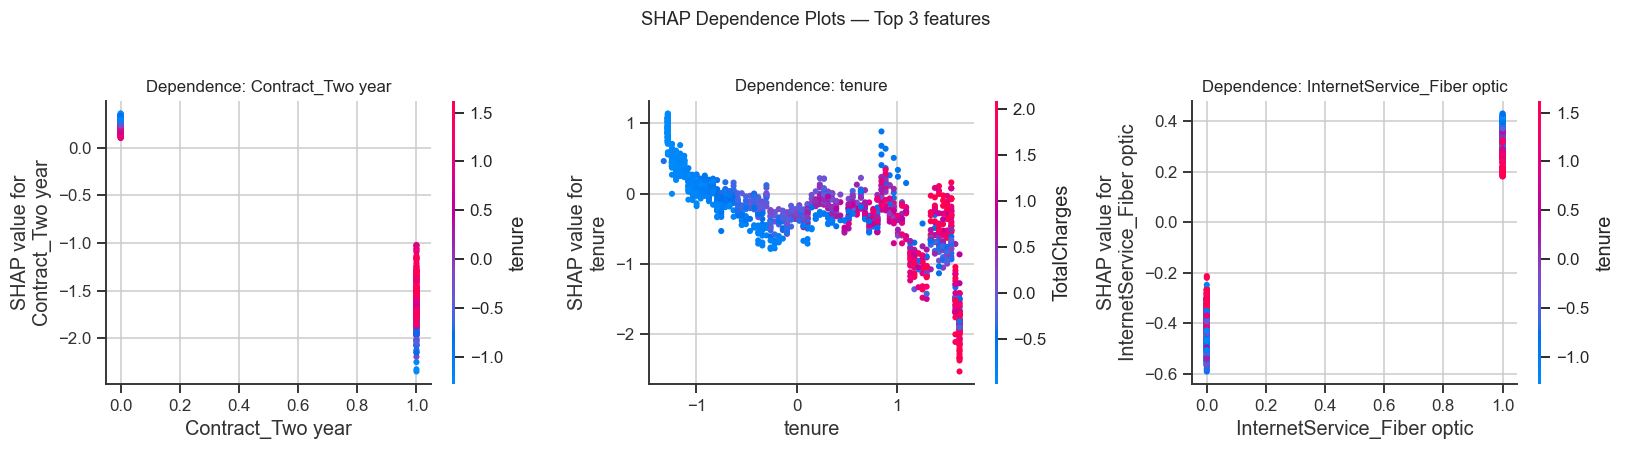


Cómo leer este gráfico:
  Eje X → valor real de la feature
  Eje Y → SHAP value de esa feature (su contribución al riesgo)
  Color → feature con mayor interacción (elegida automáticamente)


In [7]:
top3 = mean_abs_shap.index[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, top3):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_df,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence: {feat}', fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 3 features', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plot_17_shap_dependence.png', bbox_inches='tight')
plt.show()
print()
print('Cómo leer este gráfico:')
print('  Eje X → valor real de la feature')
print('  Eje Y → SHAP value de esa feature (su contribución al riesgo)')
print('  Color → feature con mayor interacción (elegida automáticamente)')

---
## 6. Waterfall Plot — explicar una predicción individual

Esta es la parte más poderosa para producción: explicar por qué el modelo predijo churn para un cliente específico. Cada barra es la contribución de una feature a esa predicción.

In [8]:
# Seleccionar un cliente con alta probabilidad de churn predicha
idx_alto_riesgo = np.argsort(y_proba_xgb)[-1]  # el de mayor riesgo
idx_bajo_riesgo = np.argsort(y_proba_xgb)[0]   # el de menor riesgo

print(f'Cliente alto riesgo  (idx={idx_alto_riesgo}): P(churn)={y_proba_xgb[idx_alto_riesgo]:.3f}  |  Real: {y_test.iloc[idx_alto_riesgo]}')
print(f'Cliente bajo riesgo  (idx={idx_bajo_riesgo}): P(churn)={y_proba_xgb[idx_bajo_riesgo]:.3f}  |  Real: {y_test.iloc[idx_bajo_riesgo]}')

Cliente alto riesgo  (idx=1109): P(churn)=0.988  |  Real: 1
Cliente bajo riesgo  (idx=94): P(churn)=0.001  |  Real: 0


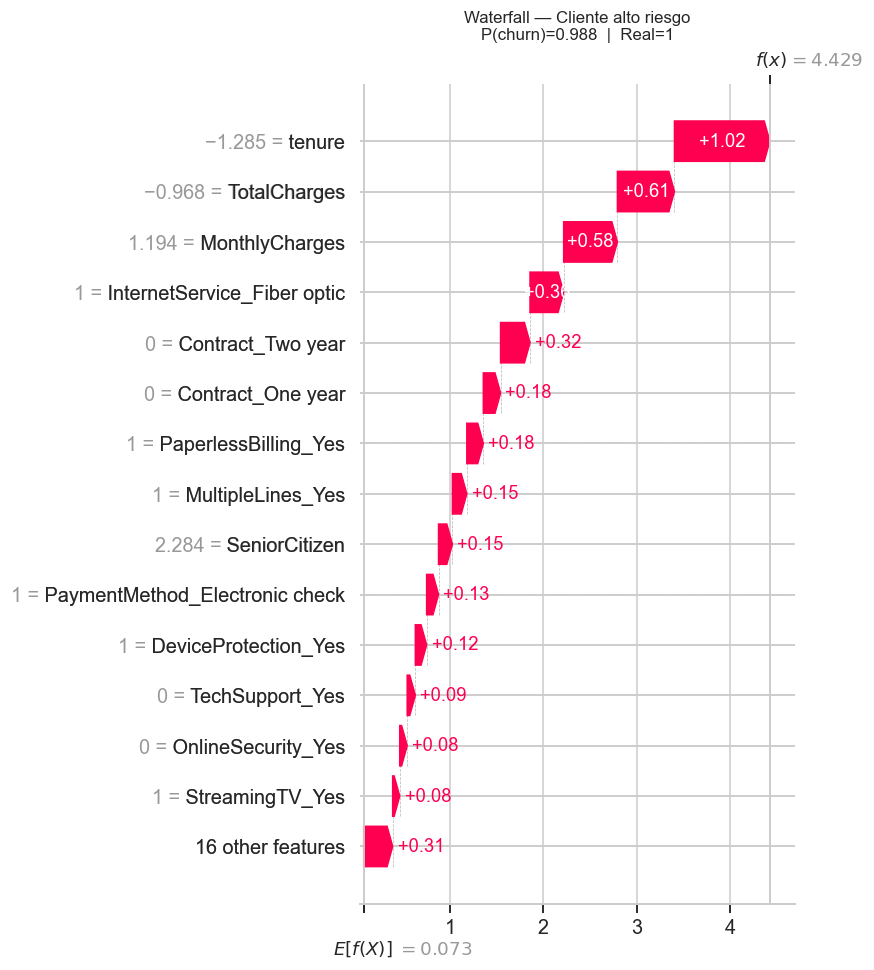

In [9]:
# Waterfall para el cliente de mayor riesgo
shap_explanation = shap.Explanation(
    values        = shap_values[idx_alto_riesgo],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[idx_alto_riesgo].values,
    feature_names = feature_names
)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_explanation, max_display=15, show=False)
plt.title(f'Waterfall — Cliente alto riesgo\nP(churn)={y_proba_xgb[idx_alto_riesgo]:.3f}  |  Real={y_test.iloc[idx_alto_riesgo]}',
          fontsize=11)
plt.tight_layout()
plt.savefig('plot_18_shap_waterfall_alto.png', bbox_inches='tight')
plt.show()

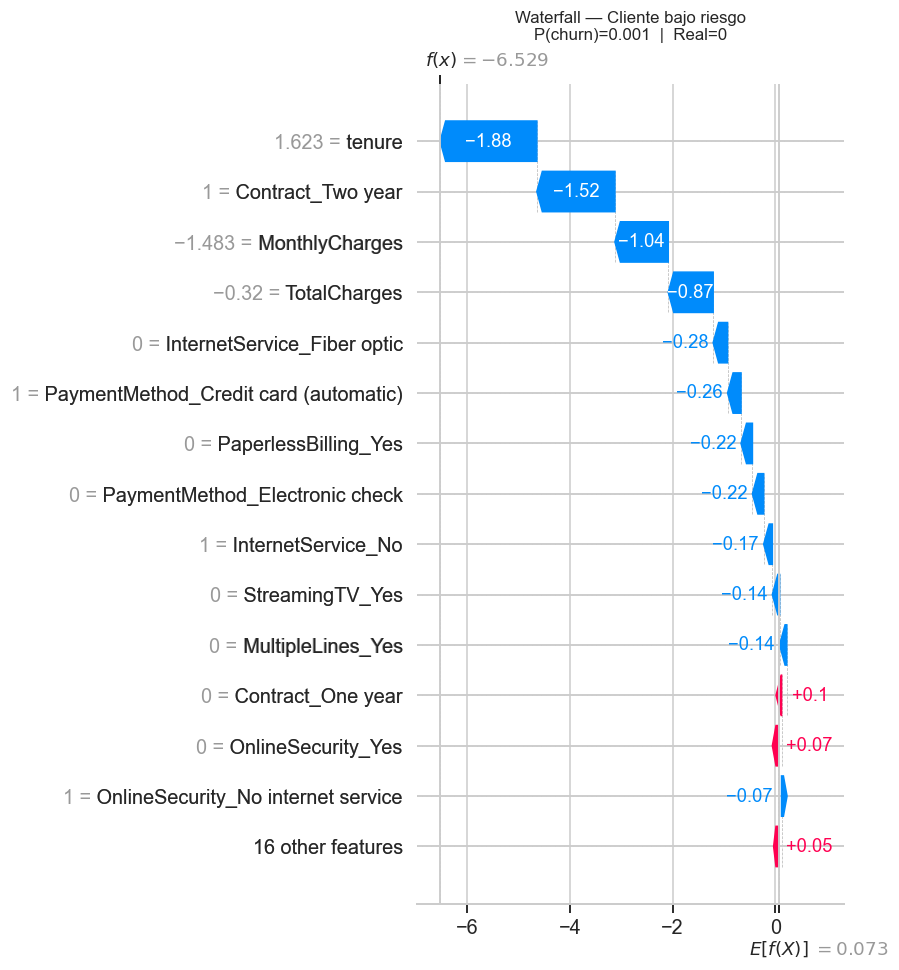

In [10]:
# Waterfall para el cliente de menor riesgo
shap_explanation_bajo = shap.Explanation(
    values        = shap_values[idx_bajo_riesgo],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[idx_bajo_riesgo].values,
    feature_names = feature_names
)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_explanation_bajo, max_display=15, show=False)
plt.title(f'Waterfall — Cliente bajo riesgo\nP(churn)={y_proba_xgb[idx_bajo_riesgo]:.3f}  |  Real={y_test.iloc[idx_bajo_riesgo]}',
          fontsize=11)
plt.tight_layout()
plt.savefig('plot_19_shap_waterfall_bajo.png', bbox_inches='tight')
plt.show()

---
## 7. Función reutilizable para producción



In [11]:
def explicar_cliente(idx: int, top_n: int = 8) -> pd.DataFrame:
    """
    Devuelve las top_n features que más contribuyeron
    a la predicción de churn para el cliente en posición idx del test set.
    """
    sv = shap_values[idx]
    fv = X_test_df.iloc[idx]

    df_exp = pd.DataFrame({
        'feature':    feature_names,
        'valor':      fv.values,
        'shap_value': sv
    })
    df_exp['|shap|'] = df_exp['shap_value'].abs()
    df_exp = df_exp.sort_values('|shap|', ascending=False).head(top_n)
    df_exp['dirección'] = df_exp['shap_value'].apply(
        lambda x: '↑ aumenta riesgo' if x > 0 else '↓ reduce riesgo'
    )
    return df_exp[['feature', 'valor', 'shap_value', 'dirección']].reset_index(drop=True)


prob = y_proba_xgb[idx_alto_riesgo]
print(f'Explicación del cliente de mayor riesgo (P(churn)={prob:.3f}):')
print(explicar_cliente(idx_alto_riesgo).to_string(index=False))

Explicación del cliente de mayor riesgo (P(churn)=0.988):
                    feature     valor  shap_value        dirección
                     tenure -1.284605    1.022735 ↑ aumenta riesgo
               TotalCharges -0.967959    0.611741 ↑ aumenta riesgo
             MonthlyCharges  1.194408    0.576427 ↑ aumenta riesgo
InternetService_Fiber optic  1.000000    0.360895 ↑ aumenta riesgo
          Contract_Two year  0.000000    0.315695 ↑ aumenta riesgo
          Contract_One year  0.000000    0.184949 ↑ aumenta riesgo
       PaperlessBilling_Yes  1.000000    0.177077 ↑ aumenta riesgo
          MultipleLines_Yes  1.000000    0.154718 ↑ aumenta riesgo


---
## 8. Guardar explainer y shap_values

In [14]:
import joblib

joblib.dump(explainer,    'shap_explainer.pkl')
np.save('shap_values.npy', shap_values)
X_test_df.to_pickle('X_test_transformed.pkl')

print('Guardado: shap_explainer.pkl, shap_values.npy, X_test_transformed.pkl')

Guardado: shap_explainer.pkl, shap_values.npy, X_test_transformed.pkl
